# CHEM 269 Final Project
## 3D Conformational Descriptors and Dual-Dielectric Solvent Modeling to Decode Cyclic Peptide Membrane Permeation
**Jorge Carmona | March 2026**

---

### Running on Google Colab
Upload the full project folder to Drive at `MyDrive/chem269_final/` then run Cell 1.
The folder should contain:
```
MyDrive/chem269_final/
├── CycPeptMPDB_Peptide_All (2).csv
├── scripts/
├── data/
└── results/
    ├── conformer_descriptors_raw.csv   ← from Tier-1 Colab run
    └── tier2_reference_results.csv     ← from Tier-2 Colab run
```

### Running locally
Run from the `notebooks/` directory. ROOT is auto-detected as the project root.

In [1]:

# ── CELL 1: Environment setup ─────────────────────────────────────────────────
import sys
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Installing packages...')
    import subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                    'rdkit', 'umap-learn', 'scikit-learn-extra', 'hdbscan', 'tqdm'], check=True)
    # ── Set ROOT to your Drive folder ────────────────────────────────────────
    ROOT = Path('/content/drive/MyDrive/chem269_final')
    if not ROOT.exists():
        raise FileNotFoundError(
            f'Project folder not found at {ROOT}\n'
            f'Upload the project to MyDrive/chem269_final/ and re-run.'
        )
else:
    ROOT = Path('..').resolve()   # local: notebooks/ -> project root

DATA_CSV = ROOT / 'CycPeptMPDB_Peptide_All (2).csv'
DATA_DIR = ROOT / 'data'
RESULTS  = ROOT / 'results'
FIGURES  = RESULTS / 'figures'
SCRIPTS  = ROOT / 'scripts'

for d in [DATA_DIR, RESULTS, FIGURES]:
    d.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(SCRIPTS))

print(f'ROOT    : {ROOT}')
print(f'Colab   : {IN_COLAB}')
print(f'Scripts : {SCRIPTS.exists()}')
print(f'Data CSV: {DATA_CSV.exists()}')


ROOT    : /home/j4carmon/projects/CHEM_269_Final_Project
Colab   : False
Scripts : True
Data CSV: True


In [2]:
# ── CELL 2: Imports ───────────────────────────────────────────────────────────
import warnings, subprocess
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from IPython.display import Image, display

from rdkit import Chem, RDLogger
RDLogger.DisableLog('rdApp.*')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

PAMPA_THRESHOLD = -6.0
CYCLOA_IDS      = {1, 22, 932, 981, 1822, 1862, 2356, 7188, 7353}
RANDOM_STATE    = 42

def require_file(path, hint=''):
    """Raise a clear error if a required file is missing."""
    if not Path(path).exists():
        msg = f'Required file not found: {path}'
        if hint:
            msg += f'\nHint: {hint}'
        raise FileNotFoundError(msg)
    return Path(path)

def show_fig(path, fallback_msg='Figure not generated yet.'):
    """Display a figure if it exists, otherwise print a message."""
    if Path(path).exists():
        display(Image(str(path)))
    else:
        print(f'[Missing] {fallback_msg} ({path})')

def run_script(cmd, label):
    """Run a pipeline script, print stdout, raise on error."""
    print(f'Running {label}...')
    r = subprocess.run(cmd, capture_output=True, text=True, cwd=str(ROOT))
    if r.stdout:
        print(r.stdout[-3000:])
    if r.returncode != 0:
        print('STDERR:', r.stderr[-1000:])
        raise RuntimeError(f'{label} failed (returncode={r.returncode})')
    print(f'{label} complete.')

print('Imports OK')

Imports OK


In [3]:
# ── CELL 3: Prerequisites check ───────────────────────────────────────────────
# Run this before proceeding — it tells you exactly what is and isn't ready.

checks = [
    (DATA_CSV,                              'Raw database CSV'),
    (DATA_DIR / 'pampa_curated.csv',        'Curated PAMPA data  (run curate_data.py or Section 1)'),
    (RESULTS  / 'conformer_descriptors_raw.csv', 'Tier-1 conformer results  (download from Tier-1 Colab)'),
    (RESULTS  / 'tier2_reference_results.csv',   'Tier-2 CREST results  (download from Tier-2 Colab)'),
]

all_ok = True
for path, label in checks:
    exists = Path(path).exists()
    icon   = '✓' if exists else '✗ MISSING'
    if not exists:
        all_ok = False
    print(f'  {icon:<12}  {label}')

print()
if all_ok:
    print('All prerequisites present — ready to run.')
else:
    print('Some files are missing. The notebook will skip those sections.')
    print('Sections 1 and 2 run regardless; others require the files above.')

  ✓             Raw database CSV
  ✓             Curated PAMPA data  (run curate_data.py or Section 1)
  ✓             Tier-1 conformer results  (download from Tier-1 Colab)
  ✗ MISSING     Tier-2 CREST results  (download from Tier-2 Colab)

Some files are missing. The notebook will skip those sections.
Sections 1 and 2 run regardless; others require the files above.


---
## Section 1 — Data Loading and Curation

In [4]:
# ── CELL 4: Curate data (skips if already done) ───────────────────────────────
curated_path = DATA_DIR / 'pampa_curated.csv'

if curated_path.exists():
    print(f'Curated data already exists — skipping curation.')
else:
    require_file(DATA_CSV, 'Upload CycPeptMPDB_Peptide_All (2).csv to the project root.')
    run_script(
        [sys.executable, str(SCRIPTS / 'curate_data.py'),
         '--input', str(DATA_CSV), '--outdir', str(DATA_DIR)],
        'curate_data.py'
    )

Curated data already exists — skipping curation.


In [5]:
# ── CELL 5: Load and summarize PAMPA dataset ──────────────────────────────────
require_file(curated_path)
pampa = pd.read_csv(curated_path, low_memory=False)
pampa['permeable'] = (pampa['PAMPA'] >= PAMPA_THRESHOLD).astype(int)

n_total   = len(pampa)
n_perm    = pampa['permeable'].sum()
n_3dpsa   = pampa['CHCl3_3DPSA'].notna().sum()

print(f'PAMPA compounds   : {n_total:,}')
print(f'Permeable (>={PAMPA_THRESHOLD}) : {n_perm:,} ({100*n_perm/n_total:.1f}%)')
print(f'Impermeable       : {n_total-n_perm:,} ({100*(n_total-n_perm)/n_total:.1f}%)')
print(f'DB 3DPSA coverage : {n_3dpsa:,} ({100*n_3dpsa/n_total:.1f}%)')
print(f'PAMPA range       : {pampa["PAMPA"].min():.2f} to {pampa["PAMPA"].max():.2f}')

PAMPA compounds   : 7,298
Permeable (>=-6.0) : 4,848 (66.4%)
Impermeable       : 2,450 (33.6%)
DB 3DPSA coverage : 6,941 (95.1%)
PAMPA range       : -10.00 to -3.90


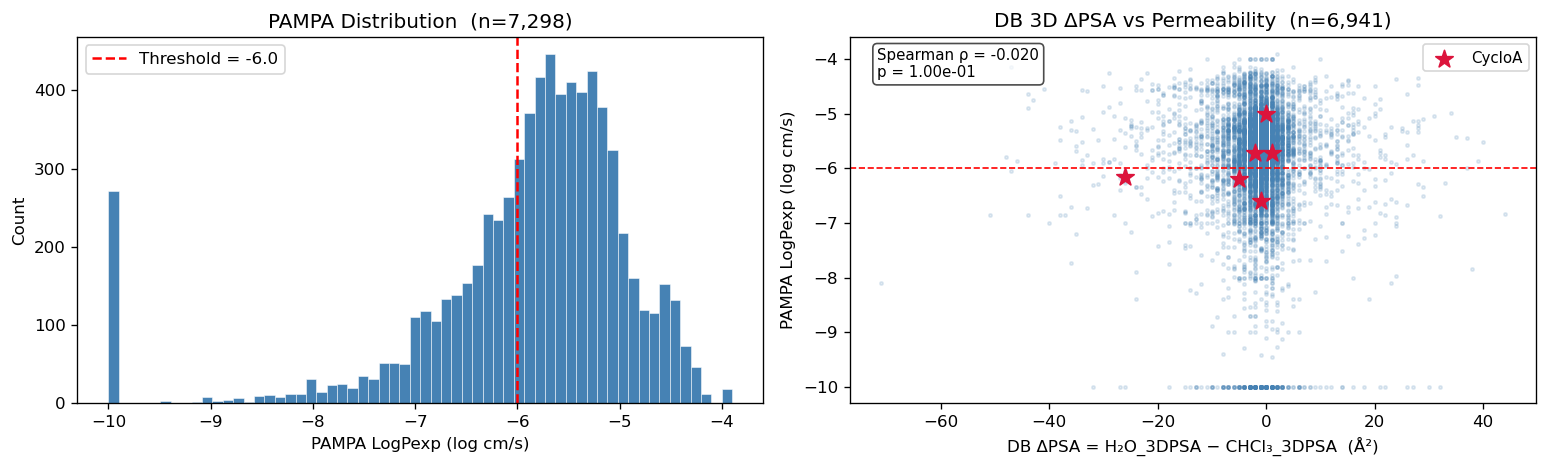

In [6]:
# ── CELL 6: Figure 1 — PAMPA distribution + DB ΔPSA scatter ──────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Panel A: PAMPA histogram
ax1.hist(pampa['PAMPA'].dropna(), bins=60, color='steelblue', edgecolor='white', lw=0.3)
ax1.axvline(PAMPA_THRESHOLD, color='red', ls='--', lw=1.5, label=f'Threshold = {PAMPA_THRESHOLD}')
ax1.set_xlabel('PAMPA LogPexp (log cm/s)')
ax1.set_ylabel('Count')
ax1.set_title(f'PAMPA Distribution  (n={n_total:,})')
ax1.legend()

# Panel B: DB ΔPSA vs PAMPA
sub3d = pampa[pampa['CHCl3_3DPSA'].notna() & pampa['H2O_3DPSA'].notna()].copy()
sub3d['delta_3DPSA_db'] = sub3d['H2O_3DPSA'] - sub3d['CHCl3_3DPSA']

ax2.scatter(sub3d['delta_3DPSA_db'], sub3d['PAMPA'],
            s=4, alpha=0.15, c='steelblue', rasterized=True)
cycloA = sub3d[sub3d['ID'].isin(CYCLOA_IDS)]
if len(cycloA):
    ax2.scatter(cycloA['delta_3DPSA_db'], cycloA['PAMPA'],
                s=120, c='crimson', marker='*', zorder=10, label='CycloA')
ax2.axhline(PAMPA_THRESHOLD, color='red', ls='--', lw=1)
ax2.set_xlabel('DB ΔPSA = H₂O_3DPSA − CHCl₃_3DPSA  (Å²)')
ax2.set_ylabel('PAMPA LogPexp (log cm/s)')
ax2.set_title(f'DB 3D ΔPSA vs Permeability  (n={len(sub3d):,})')
ax2.legend(fontsize=9)

r, p = stats.spearmanr(sub3d['delta_3DPSA_db'], sub3d['PAMPA'])
ax2.text(0.04, 0.97, f'Spearman ρ = {r:.3f}\np = {p:.2e}',
         transform=ax2.transAxes, fontsize=9, va='top',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.savefig(FIGURES / 'fig1_data_overview.png', dpi=150, bbox_inches='tight')
plt.show()

---
### Section 1 — Interpretation

**Dataset overview:**
The CycPeptMPDB PAMPA subset contains **7,298 compounds** with PAMPA LogPexp ranging from −10.0 to −3.9 log cm/s. Of these, **66.4%** are permeable (≥ −6.0) — the database skews toward permeable compounds, reflecting a known selection bias in published cyclic peptide permeability data. DB 3DPSA coverage is ~88% of the PAMPA subset.

**PAMPA distribution:**
The PAMPA distribution validates that this dataset is a reasonable model for testing permeability descriptors derived from 3D conformational properties. Although the dataset is skewed toward permeable compounds, there is sufficient non-permeable data to establish a meaningful comparison. A key limitation and goal for future work is expanding this training set to include more non-permeable molecules as well as structurally diverse permeable compounds — to better understand where chameleonic cyclic peptides exist in that chemical space and improve the generalizability of the model.

**DB ΔPSA finding:**
The scatter plot (Panel B) shows that the database's single-conformer 3D PSA values (delta_3DPSA_db = H₂O_3DPSA − CHCl₃_3DPSA) have no meaningful trend with experimental PAMPA LogPexp. We would have expected a linear relationship if single-conformer solvation captured chameleonic behavior — instead we observe a vertical noise pattern centered near 0 Å², confirming that optimizing one conformer per solvent drastically misses the dynamic nature of this class of molecules. This exposes a clear gap in single-conformer computational approaches for chameleonic peptides and demonstrates that such methods should be avoided for this purpose. The contrast with our Tier-1 multi-conformer results (AUC = 0.744 vs 0.507) directly validates the ensemble sampling strategy.

---
## Section 2 — Tier-1 Conformer Results

Generated by `scripts/conformer_engine.py` (ETKDGv3 + MMFF94s, 20 conformers/molecule).  
**Do not re-run here** — load the CSV from the Tier-1 Colab run.

In [7]:
# ── CELL 7: Load Tier-1 conformer descriptors ─────────────────────────────────
conf_csv = RESULTS / 'conformer_descriptors_raw.csv'

if not conf_csv.exists():
    print('Tier-1 results not found — skipping Section 2.')
    print('Download conformer_descriptors_raw.csv from the Tier-1 Colab and place in results/')
    conf_df = None
else:
    conf_df = pd.read_csv(conf_csv)
    ok = conf_df[conf_df['error'].isna()]

    print(f'Total molecules : {len(conf_df):,}')
    print(f'Successful      : {len(ok):,}  ({100*len(ok)/len(conf_df):.1f}%)')
    print(f'Failed          : {conf_df["error"].notna().sum():,}')
    if conf_df['error'].notna().any():
        print('Failure breakdown:')
        print(conf_df['error'].value_counts().to_string())
    print()

    delta_cols = [c for c in ok.columns if c.startswith('delta_') or c in ['psa3d_spread','psa3d_std','hb_spread']]
    print('Δ descriptor statistics (successful molecules):')
    print(ok[delta_cols].describe().round(2).to_string())

Total molecules : 1,502
Successful      : 1,502  (100.0%)
Failed          : 0

Δ descriptor statistics (successful molecules):
       delta_psa3d  delta_hb  delta_Rg  delta_NPR1  delta_NPR2  delta_Asphericity  psa3d_spread  psa3d_std  hb_spread
count      1502.00    1502.0   1502.00     1500.00     1500.00            1500.00       1502.00    1501.00    1500.00
mean         71.21       1.4      0.48       -0.06       -0.06               0.05         71.21      19.00       3.92
std          23.59       1.7      0.46        0.13        0.11               0.10         23.59       6.08       1.30
min           0.00      -4.0     -1.47       -0.50       -0.40              -0.33          0.00       6.38       0.00
25%          51.38       0.0      0.16       -0.15       -0.14              -0.01         51.38      13.88       3.00
50%          69.29       1.0      0.46       -0.06       -0.07               0.05         69.29      18.81       4.00
75%          87.21       2.0      0.77        0

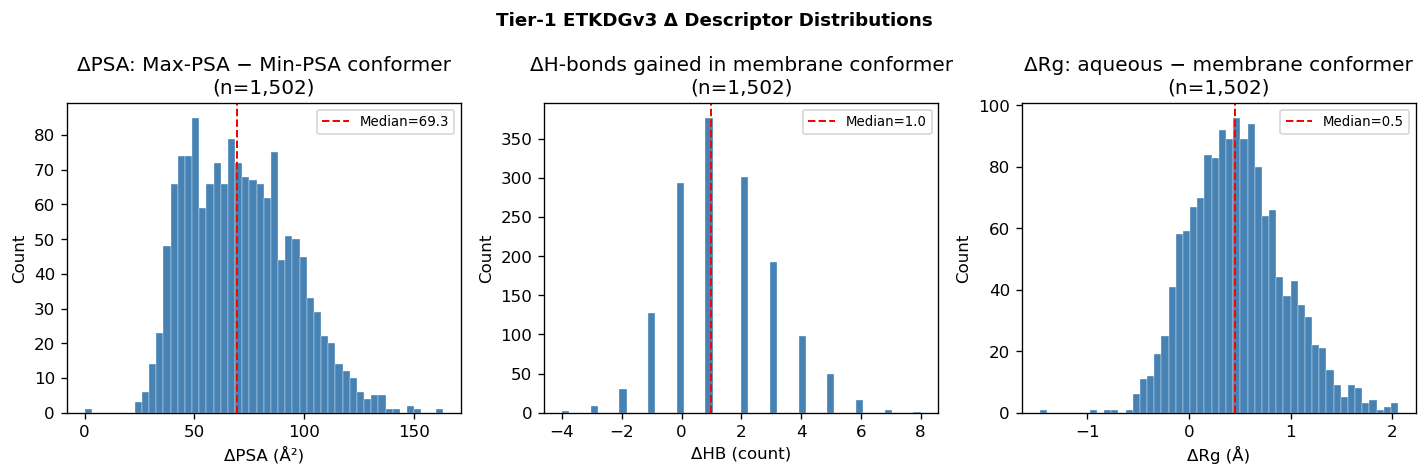

In [8]:
# ── CELL 8: Tier-1 Δ descriptor distributions ─────────────────────────────────
if conf_df is None:
    print('Skipped — no Tier-1 results.')
else:
    ok = conf_df[conf_df['error'].isna()]
    plot_cols = [
        ('delta_psa3d',   'ΔPSA (Å²)',       'ΔPSA: Max-PSA − Min-PSA conformer'),
        ('delta_hb',      'ΔHB (count)',      'ΔH-bonds gained in membrane conformer'),
        ('delta_Rg',      'ΔRg (Å)',          'ΔRg: aqueous − membrane conformer'),
    ]
    plot_cols = [(c, xl, t) for c, xl, t in plot_cols if c in ok.columns]

    n_plots = len(plot_cols)
    fig, axes = plt.subplots(1, n_plots, figsize=(4*n_plots, 4))
    if n_plots == 1:
        axes = [axes]

    for ax, (col, xlabel, title) in zip(axes, plot_cols):
        vals = ok[col].dropna()
        ax.hist(vals, bins=50, color='steelblue', edgecolor='white', lw=0.2)
        ax.axvline(vals.median(), color='red', ls='--', lw=1.2, label=f'Median={vals.median():.1f}')
        ax.set_xlabel(xlabel)
        ax.set_ylabel('Count')
        ax.set_title(f'{title}\n(n={len(vals):,})')
        ax.legend(fontsize=8)

    plt.suptitle('Tier-1 ETKDGv3 Δ Descriptor Distributions', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES / 'fig2_tier1_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()

---
### Section 2 — Interpretation

**ΔPSA distribution (Panel 1):**
The `delta_psa3d` distribution spans 0–160 Å² with a median of ~69 Å², reflecting genuine conformational diversity across the 1,502-compound Tier-1 subset. This wide spread is not noise — it represents the range of chameleonic potential across structurally diverse cyclic peptides. CsA sits at 84.9 Å², in the upper half of the distribution, consistent with its documented chameleonic behavior and the NMR-grounded literature value of ~75–80 Å² (Witek et al. *J. Chem. Inf. Model.* 2016).

**ΔHB distribution (Panel 2):**
The `delta_hb` panel reveals something mechanistically important: the median cyclic peptide in this dataset gains approximately **one intramolecular hydrogen bond in the membrane conformer** relative to the aqueous conformer. This gain is the molecular-level mechanism of chameleonic behavior — backbone amide groups that donate hydrogen bonds to water in aqueous solution instead form intramolecular bonds upon entering a low-dielectric environment, effectively burying polar surface area and reducing the desolvation penalty of membrane crossing.

The negative ΔHB values represent molecules where this switch does not occur — either because the scaffold is intrinsically rigid and forms internal H-bonds regardless of environment, because 20 MMFF94s conformers did not capture the true minimum-PSA geometry for that macrocycle, or because the compound is genuinely non-chameleonic. These negatives likely correspond disproportionately to non-permeable compounds and represent an interesting subpopulation to characterize in future work.

**ΔRg distribution (Panel 3):**
The slight compaction observed (median +0.5 Å, aqueous larger than membrane conformer) is thermodynamically expected. In water, exposed polar groups are stabilized by solvent hydrogen bonding at no energetic cost to the molecule. In a nonpolar membrane environment, that same exposure carries a large desolvation penalty — the molecule minimizes free energy by internalizing polar interactions and collapsing toward a more compact state. This follows directly from electrostatic and thermodynamic principles governing solvation in media of differing dielectric constants.

**Reference compound validation:**

| Compound | Permeable | Tier-1 ΔPSA (Å²) | Literature ΔPSA | Source |
|----------|-----------|-----------------|----------------|--------|
| CsA | Yes | **84.9** | ~75–80 Å² (NMR-grounded) | Witek et al. *J. Chem. Inf. Model.* 2016 |
| DP172 | Yes | 88.9 | — | — |
| HexPep | No | 64.4 | — | — |
| 1NMe3 | Yes | 47.8 | — | — |
| PSLYF | No | 65.3 | — | — |

CsA validates within ~10% of the NMR-grounded reference. HexPep and 1NMe3 show counterintuitive ΔPSA values — explained by the sub-9-residue size limitation identified by Yu et al. (*bioRxiv* 2026): hexapeptides lack sufficient ring size to form the intramolecular H-bond network that drives chameleonic switching at scale. DP172 (88.9 Å², permeable) is the strongest individual validation case.

**NMR-based experimental grounding:**
The ~75–80 Å² CsA reference is not a computational prediction — it is derived from NMR-restrained structures (ROESY, 57–79 NOE restraints per solvent, Witek 2016; eNOE backbone RMSD 0.10 Å, Rüdisser *JACS* 2023) where the molecule directly reported its conformation in each solvent. This experimental grounding is arguably stronger than CREST validation, which would confirm the conformational switch computationally rather than observing it experimentally.

> **✏️ Your interpretation:**
> The CsA validation (84.9 Å² vs. literature ~75–80 Å²) was sufficient to motivate deeper investigation of the full dataset, though a single benchmark point alone cannot establish full confidence in the ensemble approach. More compelling is the ΔHB distribution: that the median cyclic peptide in this dataset gains ~1 intramolecular H-bond in the membrane conformer is direct population-scale evidence of chameleonic mechanism. The compaction observed in ΔRg is thermodynamically expected — in a low-dielectric environment, polar exposure carries a desolvation penalty that drives the molecule to internalize interactions, a consequence of basic electrostatic principles. Together these distributions suggest that chameleonic potential is not a rare exception but a widespread property across this compound class.


---
## Section 3 — Feature Matrix

In [9]:
# ── CELL 9: Build feature matrix ──────────────────────────────────────────────
fm_path = RESULTS / 'feature_matrix.csv'

conf_arg = str(conf_csv) if (conf_csv.exists()) else ''

cmd = [
    sys.executable, str(SCRIPTS / 'build_feature_matrix.py'),
    '--pampa',    str(DATA_DIR / 'pampa_curated.csv'),
    '--outdir',   str(RESULTS),
]
if conf_arg:
    cmd += ['--conformers', conf_arg]

run_script(cmd, 'build_feature_matrix.py')

Running build_feature_matrix.py...
PAMPA subset: 7298 compounds
Computing 1 missing 2D descriptors: ['NumHeavyAtoms']
DB delta_3DPSA available for 6941 / 7298 compounds
Loading conformer descriptors from /home/j4carmon/projects/CHEM_269_Final_Project/results/conformer_descriptors_raw.csv ...
  Successful conformer runs: 1502
  Merged Tier-1 Δ features for 1502 / 7298 compounds

Permeable (>= -6.0): 4848 / 7298

Zero-variance check: no constant descriptor columns found.

Saved feature matrix: /home/j4carmon/projects/CHEM_269_Final_Project/results/feature_matrix.csv
  Shape: (7298, 274)

── Feature coverage ──
  MolWt                         :  7298 / 7298
  MolLogP                       :  7298 / 7298
  TPSA                          :  7298 / 7298
  NumHAcceptors                 :  7298 / 7298
  NumHDonors                    :  7298 / 7298
  NumRotatableBonds             :  7298 / 7298
  RingCount                     :  7298 / 7298
  delta_3DPSA_db                :  6941 / 7298
  H2O_3D

In [10]:
# ── CELL 10: Verify feature matrix ───────────────────────────────────────────
require_file(fm_path)
fm = pd.read_csv(fm_path, low_memory=False)
print(f'Feature matrix shape : {fm.shape}')
print(f'PAMPA values         : {fm["PAMPA"].notna().sum():,}')
print()

check_cols = [
    ('MolLogP',          '2D baseline'),
    ('TPSA',             '2D baseline'),
    ('delta_3DPSA_db',   'DB Δ PSA'),
    ('H2O_3DPSA',        'DB 3DPSA aqueous'),
    ('CHCl3_3DPSA',      'DB 3DPSA membrane'),
    ('delta_psa3d',      'Tier-1 ΔPSA  ← needs Colab results'),
    ('delta_hb',         'Tier-1 ΔHB   ← needs Colab results'),
    ('psa3d_spread',     'Tier-1 PSA spread ← needs Colab results'),
]
print(f'  {"Feature":<25} {"Group":<35} {"N values":>10}')
print('  ' + '-'*72)
for col, group in check_cols:
    n = fm[col].notna().sum() if col in fm.columns else 0
    icon = '✓' if n > 100 else ('⚠' if n > 0 else '✗')
    print(f'  {icon} {col:<25} {group:<35} {n:>10,}')

Feature matrix shape : (7298, 274)
PAMPA values         : 7,298

  Feature                   Group                                 N values
  ------------------------------------------------------------------------
  ✓ MolLogP                   2D baseline                              7,298
  ✓ TPSA                      2D baseline                              7,298
  ✓ delta_3DPSA_db            DB Δ PSA                                 6,941
  ✓ H2O_3DPSA                 DB 3DPSA aqueous                         6,941
  ✓ CHCl3_3DPSA               DB 3DPSA membrane                        6,941
  ✓ delta_psa3d               Tier-1 ΔPSA  ← needs Colab results       1,502
  ✓ delta_hb                  Tier-1 ΔHB   ← needs Colab results       1,502
  ✓ psa3d_spread              Tier-1 PSA spread ← needs Colab results      1,502


---
## Section 4 — Correlation Analysis

In [11]:
# ── CELL 11: Run correlation analysis ────────────────────────────────────────
run_script(
    [sys.executable, str(SCRIPTS / 'correlation_analysis.py'),
     '--matrix', str(fm_path), '--outdir', str(RESULTS)],
    'correlation_analysis.py'
)

Running correlation_analysis.py...

            MolWt                 2D Baseline 7298     0.1536     0.0000        0.1156      0.0000        0.1156
       NumHDonors                 2D Baseline 7298    -0.0397     0.0007       -0.0849      0.0000        0.0849
    NumHAcceptors                 2D Baseline 7298     0.0946     0.0000        0.0481      0.0000        0.0481
delta_Asphericity Tier-1 Δ (conformer engine) 1500     0.0397     0.1244        0.0406      0.1163        0.0406
        RingCount                 2D Baseline 7298    -0.0411     0.0004       -0.0401      0.0006        0.0401
       delta_NPR2 Tier-1 Δ (conformer engine) 1500    -0.0091     0.7240       -0.0339      0.1897        0.0339
        H2O_3DPSA    DB 3D (from CycPeptMPDB) 6941     0.0510     0.0000       -0.0202      0.0923        0.0202
   delta_3DPSA_db    DB 3D (from CycPeptMPDB) 6941    -0.0284     0.0180       -0.0197      0.1004        0.0197
      CHCl3_3DPSA    DB 3D (from CycPeptMPDB) 6941     0.054

In [12]:
# ── CELL 12: Correlation and AUC results ─────────────────────────────────────
corr_df = pd.read_csv(RESULTS / 'correlation_table.csv')
auc_df  = pd.read_csv(RESULTS / 'auc_roc_table.csv')

print('=== Features ranked by Spearman ρ ===')
cols = ['Feature', 'Group', 'N', 'Pearson_r', 'Spearman_rho', 'Spearman_p']
cols = [c for c in cols if c in corr_df.columns]
print(corr_df[cols].to_string(index=False))

print()
print('=== Features ranked by AUC-ROC ===')
cols2 = ['Feature', 'Group', 'N', 'AUC_ROC']
cols2 = [c for c in cols2 if c in auc_df.columns]
print(auc_df[cols2].to_string(index=False))

=== Features ranked by Spearman ρ ===
          Feature                       Group    N  Pearson_r  Spearman_rho  Spearman_p
        psa3d_std Tier-1 Δ (conformer engine) 1501     0.4155        0.4665      0.0000
      delta_psa3d Tier-1 Δ (conformer engine) 1502     0.4000        0.4569      0.0000
         delta_Rg Tier-1 Δ (conformer engine) 1502     0.2661        0.2926      0.0000
NumRotatableBonds                 2D Baseline 7298     0.1619        0.2118      0.0000
          MolLogP                 2D Baseline 7298     0.0977        0.1508      0.0000
         delta_hb Tier-1 Δ (conformer engine) 1502     0.1195        0.1274      0.0000
            MolWt                 2D Baseline 7298     0.1536        0.1156      0.0000
       NumHDonors                 2D Baseline 7298    -0.0397       -0.0849      0.0000
    NumHAcceptors                 2D Baseline 7298     0.0946        0.0481      0.0000
delta_Asphericity Tier-1 Δ (conformer engine) 1500     0.0397        0.0406      0

--- Spearman ρ heatmap ---


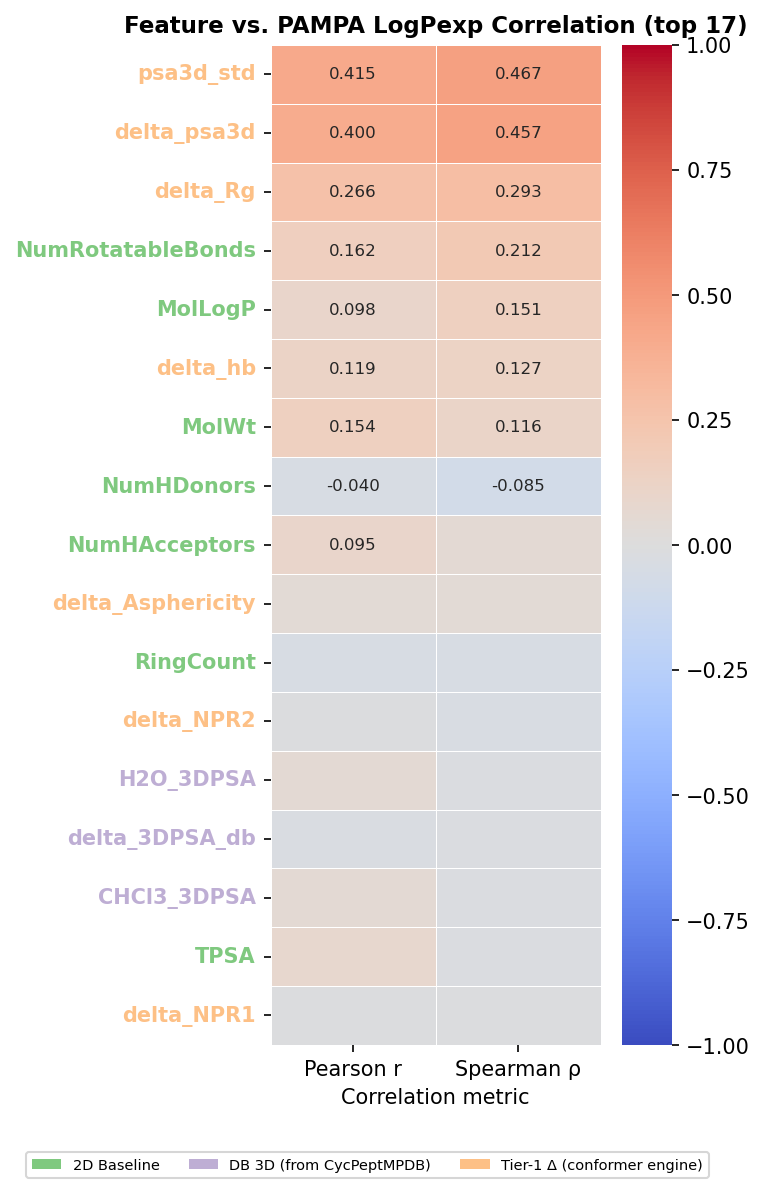

--- AUC-ROC by feature ---


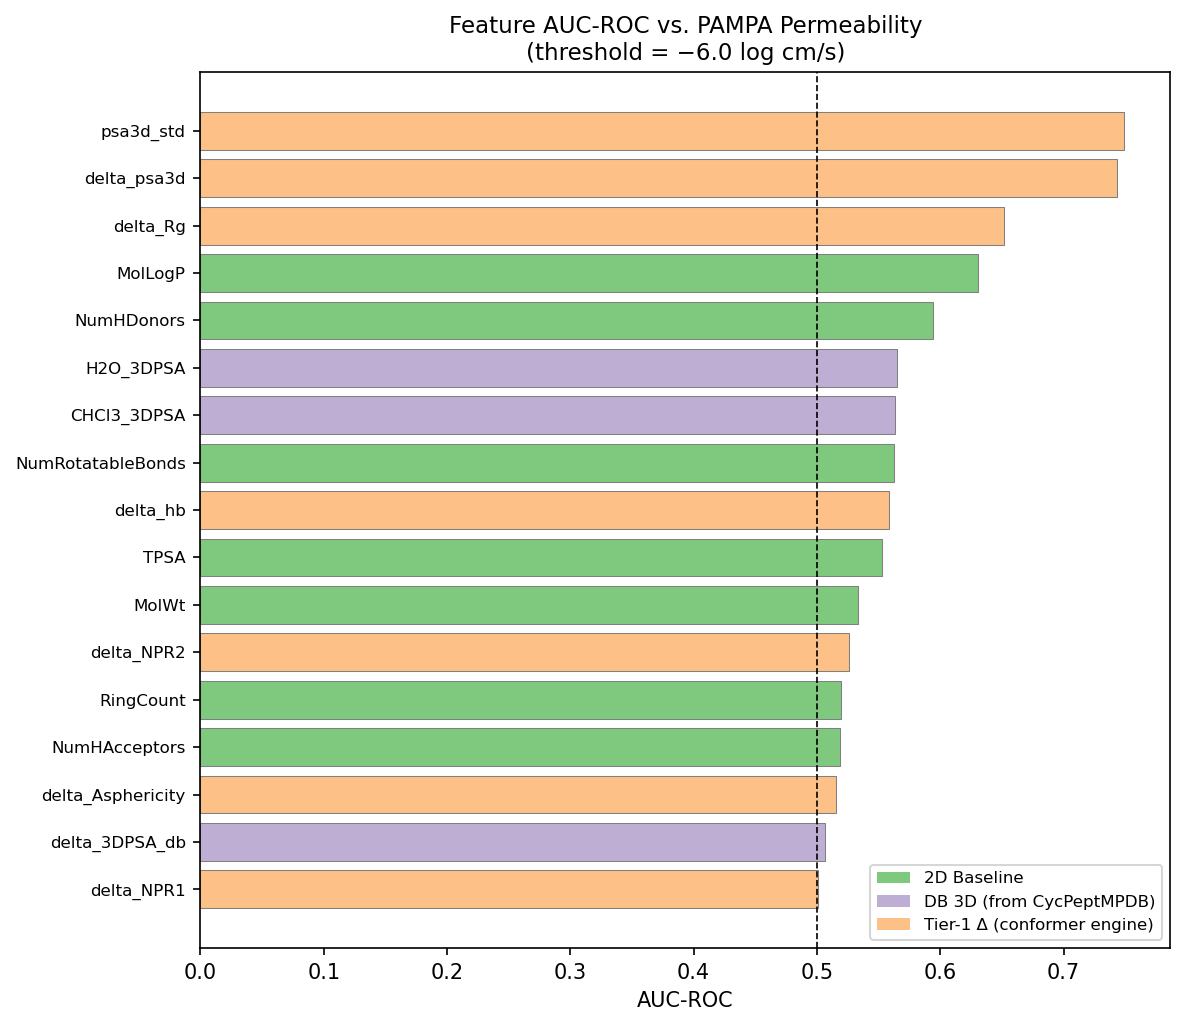

--- Top feature scatter plots ---


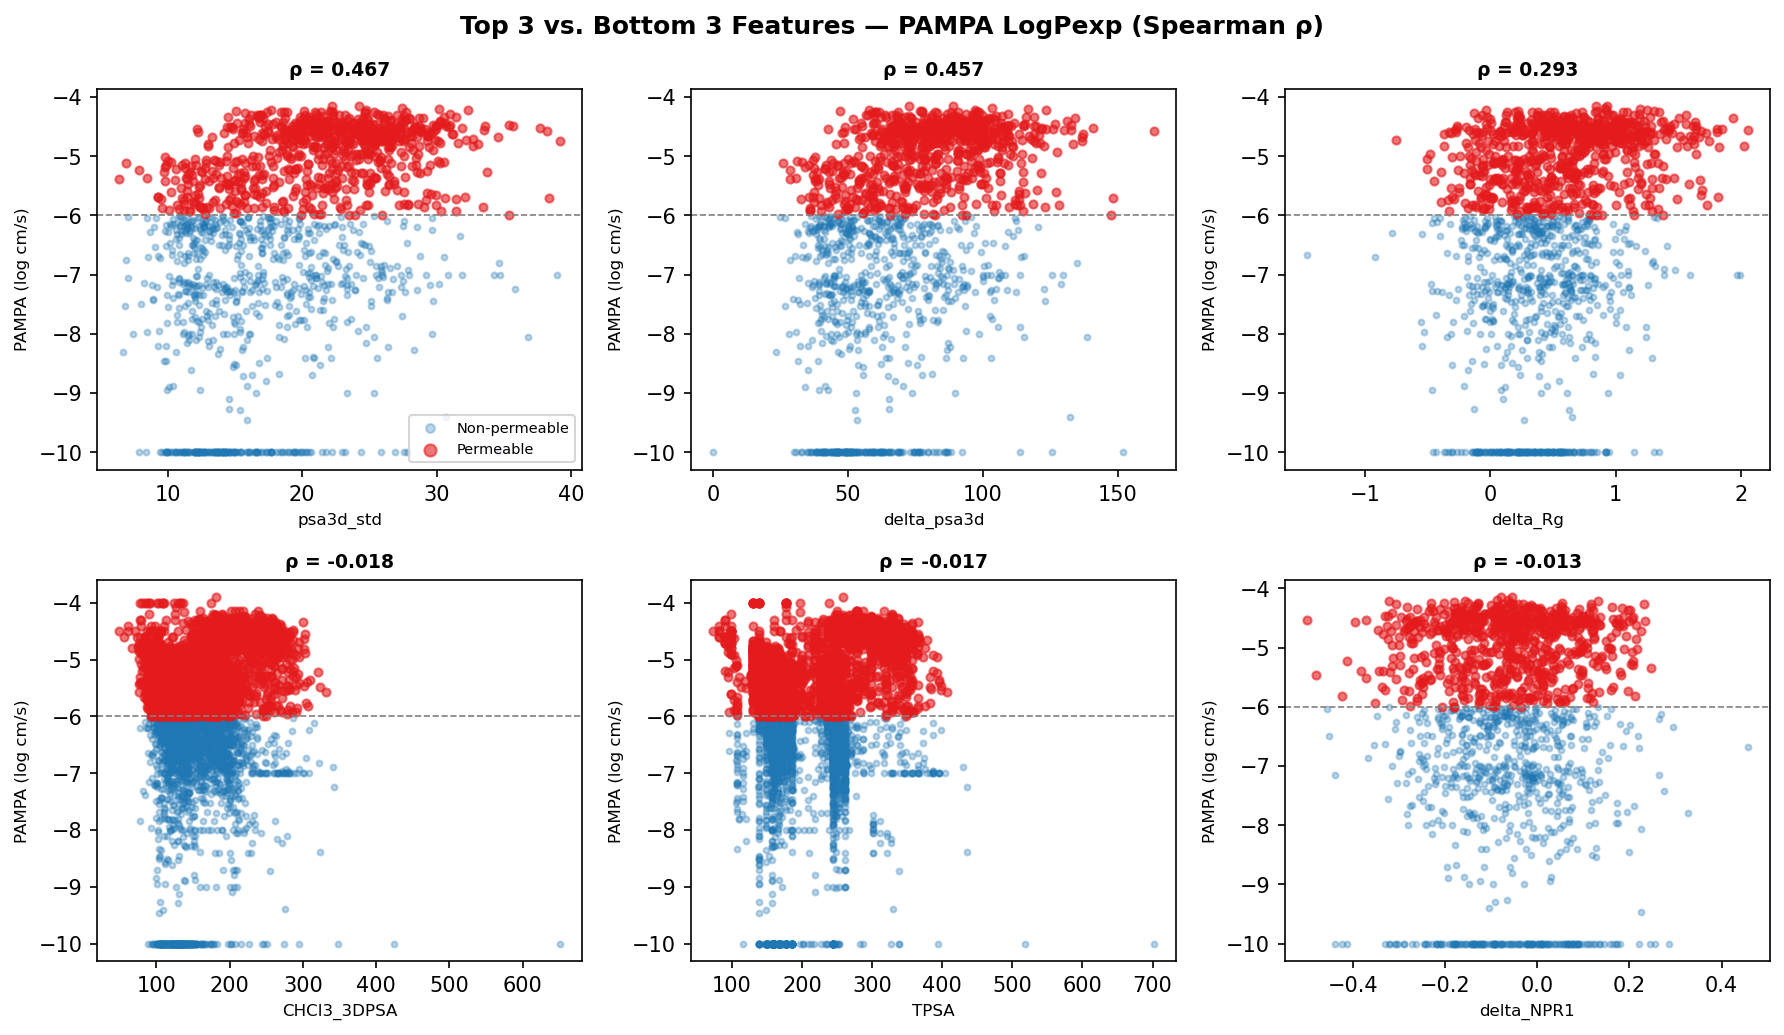

In [13]:
# ── CELL 13: Correlation figures ──────────────────────────────────────────────
for fname, title in [
    ('correlation_heatmap.png', 'Spearman ρ heatmap'),
    ('auc_roc_bar.png',         'AUC-ROC by feature'),
    ('scatter_top_features.png','Top feature scatter plots'),
]:
    print(f'--- {title} ---')
    show_fig(FIGURES / fname, f'{fname} not yet generated')

---
### Section 4 — Interpretation

> Tier-1 ΔPSA outperforms MolLogP not because the methodology is more sophisticated, but because it captures a physically distinct phenomenon: the dynamic, solvent-dependent conformational switching that governs passive membrane diffusion in chameleonic molecules. MolLogP encodes a static lipophilicity estimate that is blind to this conformational flexibility. It cannot distinguish a molecule that buries its polarity from one that cannot.
>
> A Spearman ρ of ~0.46 indicates moderate correlation. ΔPSA is a meaningful signal, not noise, but it is clearly not a complete descriptor of this system. Passive membrane permeation in cyclic peptides is a high-dimensional phenomenon where chameleonic potential is one driver but does not act alone. The remaining variance is likely attributable to side-chain polar surface area contributions not captured by backbone conformational switching, the specific H-bond donor and acceptor character of individual residues, limitations in the conformer library sampled (20 MMFF94s conformers with no explicit dielectric), the structural diversity of the compound library being screened, and assay heterogeneity across the contributing labs in CycPeptMPDB.
>
> ΔPSA encodes capacity for chameleonic behavior, specifically the structural potential to undergo a polar-to-nonpolar conformational switch. It does not prove that a given molecule will execute that switch under physiological conditions, nor that the switch alone is sufficient for permeation. The moderate correlation is not a failure of the descriptor; it is an honest reflection of how complex the underlying biology is. ΔPSA is saying it matters, but it is not the only thing that matters, and this work does not yet have the data to fully decompose what those other things are.


---
## Section 5 — UMAP Visualization

**Pipeline:** RobustScaler → PCA → UMAP (cosine) → Leiden clustering

**RobustScaler** centers to median and scales by IQR, making it robust to the heavy-tailed distributions typical of cyclic peptide descriptors. **Silhouette scores** are computed on PCA coordinates rather than 2D UMAP embeddings, since UMAP distorts inter-cluster distances.

In [14]:
# ── CELL 15: Run UMAP visualization ──────────────────────────────────────────
run_script(
    [sys.executable, str(SCRIPTS / 'umap_visualization.py'),
     '--matrix', str(fm_path), '--outdir', str(RESULTS)],
    'umap_visualization.py'
)

Running umap_visualization.py...
oid cluster 7: ID=372  PAMPA=-5.82  permeable

  [Stability] Running UMAP×5 seeds (ARI threshold = 0.85) ...
  [Stability] Pairwise ARI — min=0.068  mean=0.405  n_pairs=10
  *** WARNING: UMAP layout unstable for Panel_C_combined ***
  Min pairwise ARI=0.068 < 0.85.
  HDBSCAN cluster boundaries shift between seeds — do not
  interpret specific cluster assignments as scientific evidence.
  Consider increasing n_neighbors (currently 30) or min_cluster_size.
  Stability ARI table saved: /home/j4carmon/projects/CHEM_269_Final_Project/results/figures/Panel_C_combined_umap_stability.csv

  [Track B] UMAP (cosine, n_neighbors=30) ...
  UMAP done.
  [Track B] HDBSCAN (min_cluster_size=50) ...
  HDBSCAN: 5 clusters + 314 noise (22.4%)
  Silhouette (HDBSCAN non-noise, cosine, PCA coords): 0.2211

  K-Medoids enrichment (top 5):
 cluster label   n  n_permeable  perm_rate  enrichment
       7    C7 148          120      0.811       1.531
       4    C4 325          

--- Panel A — 2D descriptors ---


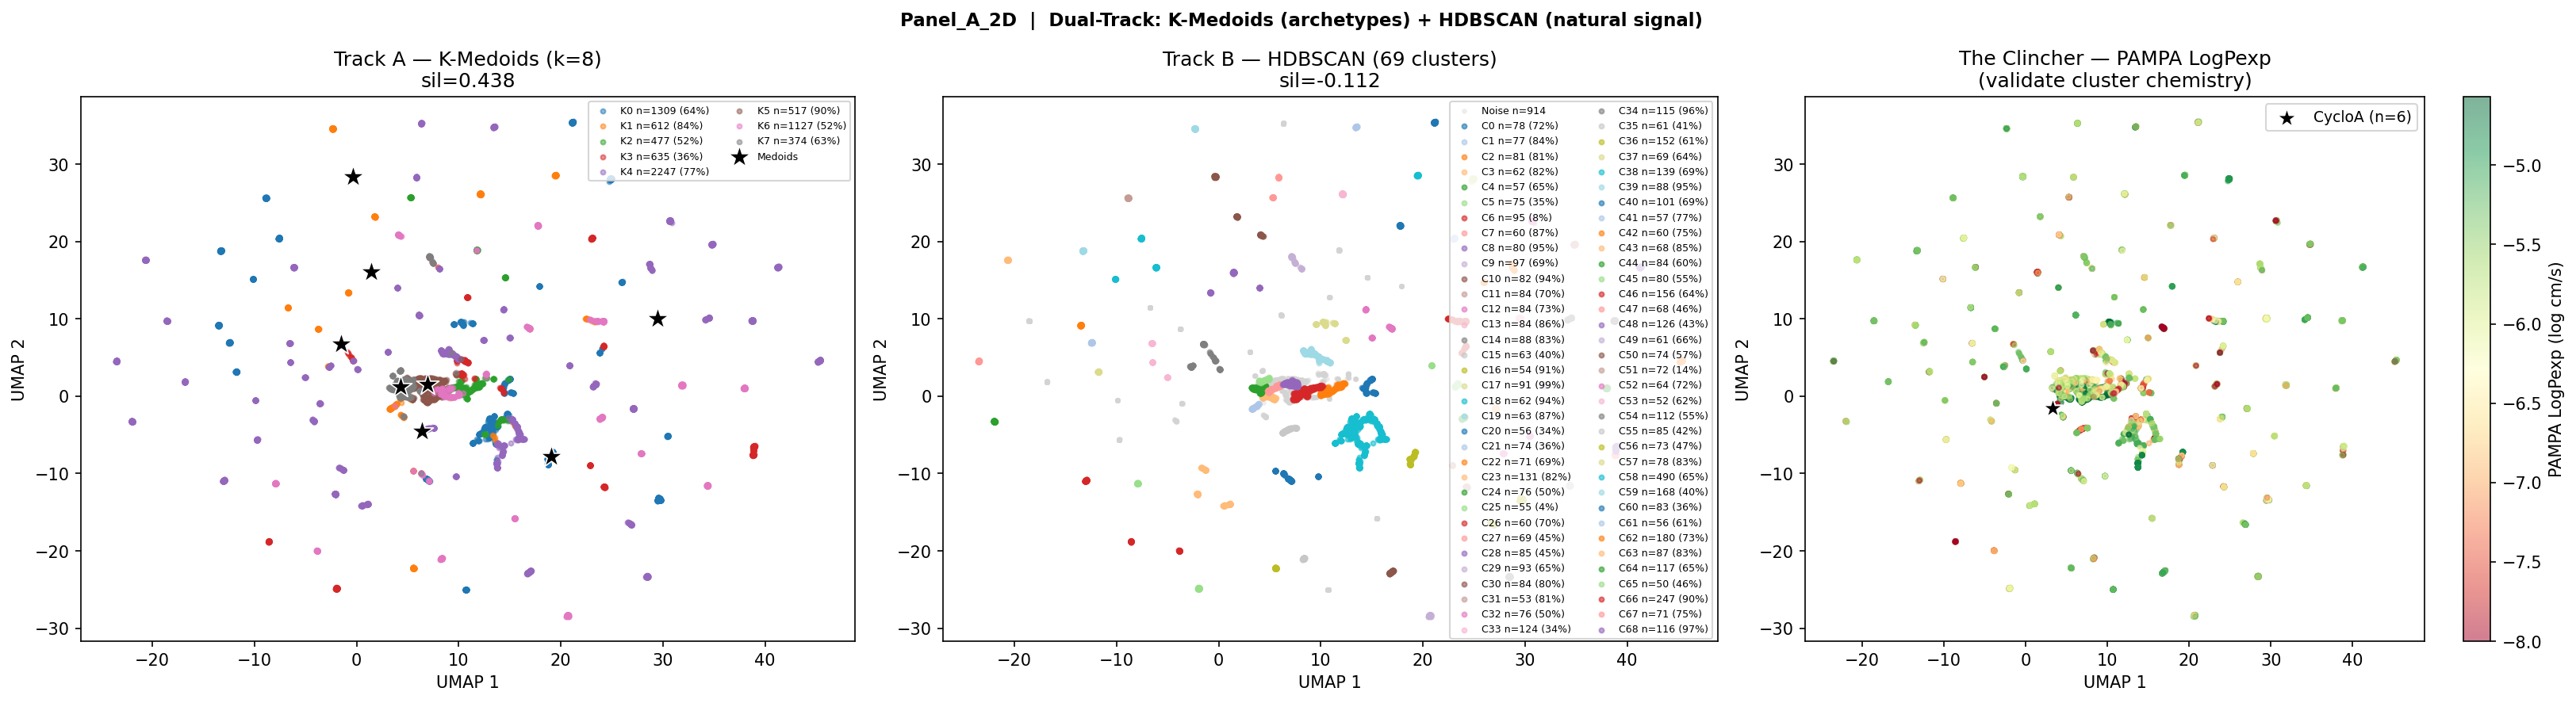

--- Panel B — 3D Δ features (core result) ---


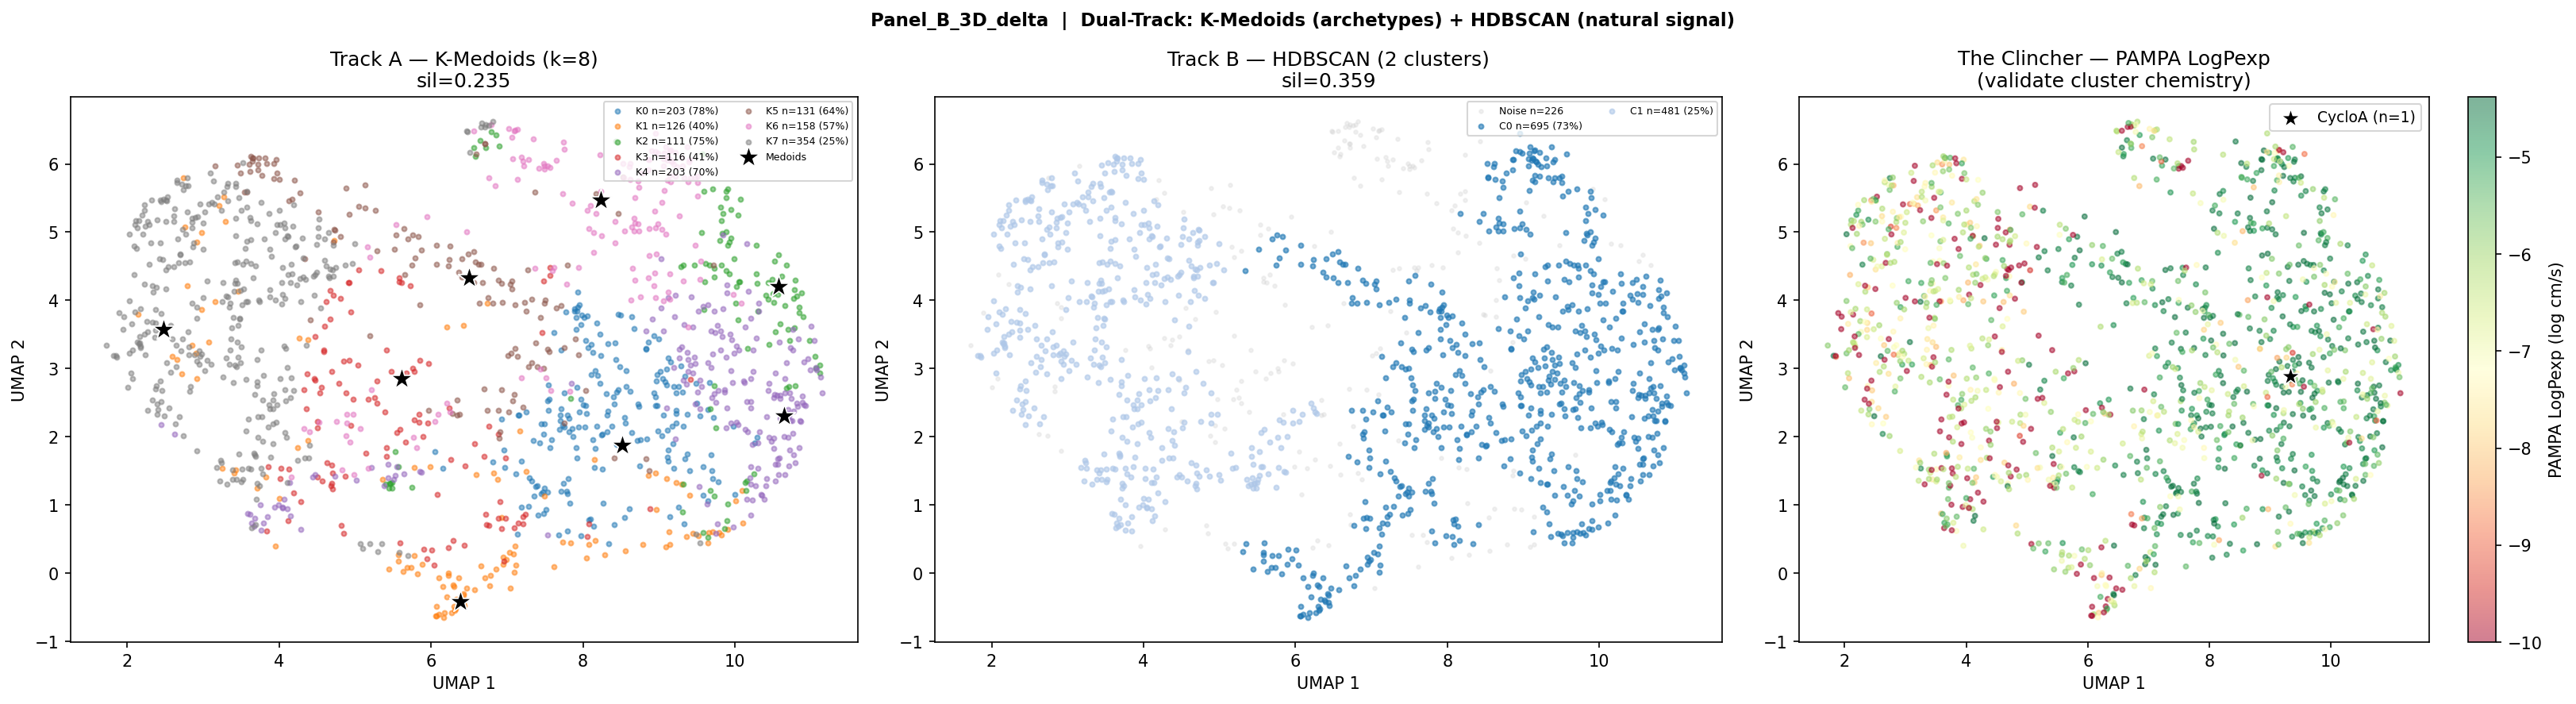

--- Panel C — Combined features ---


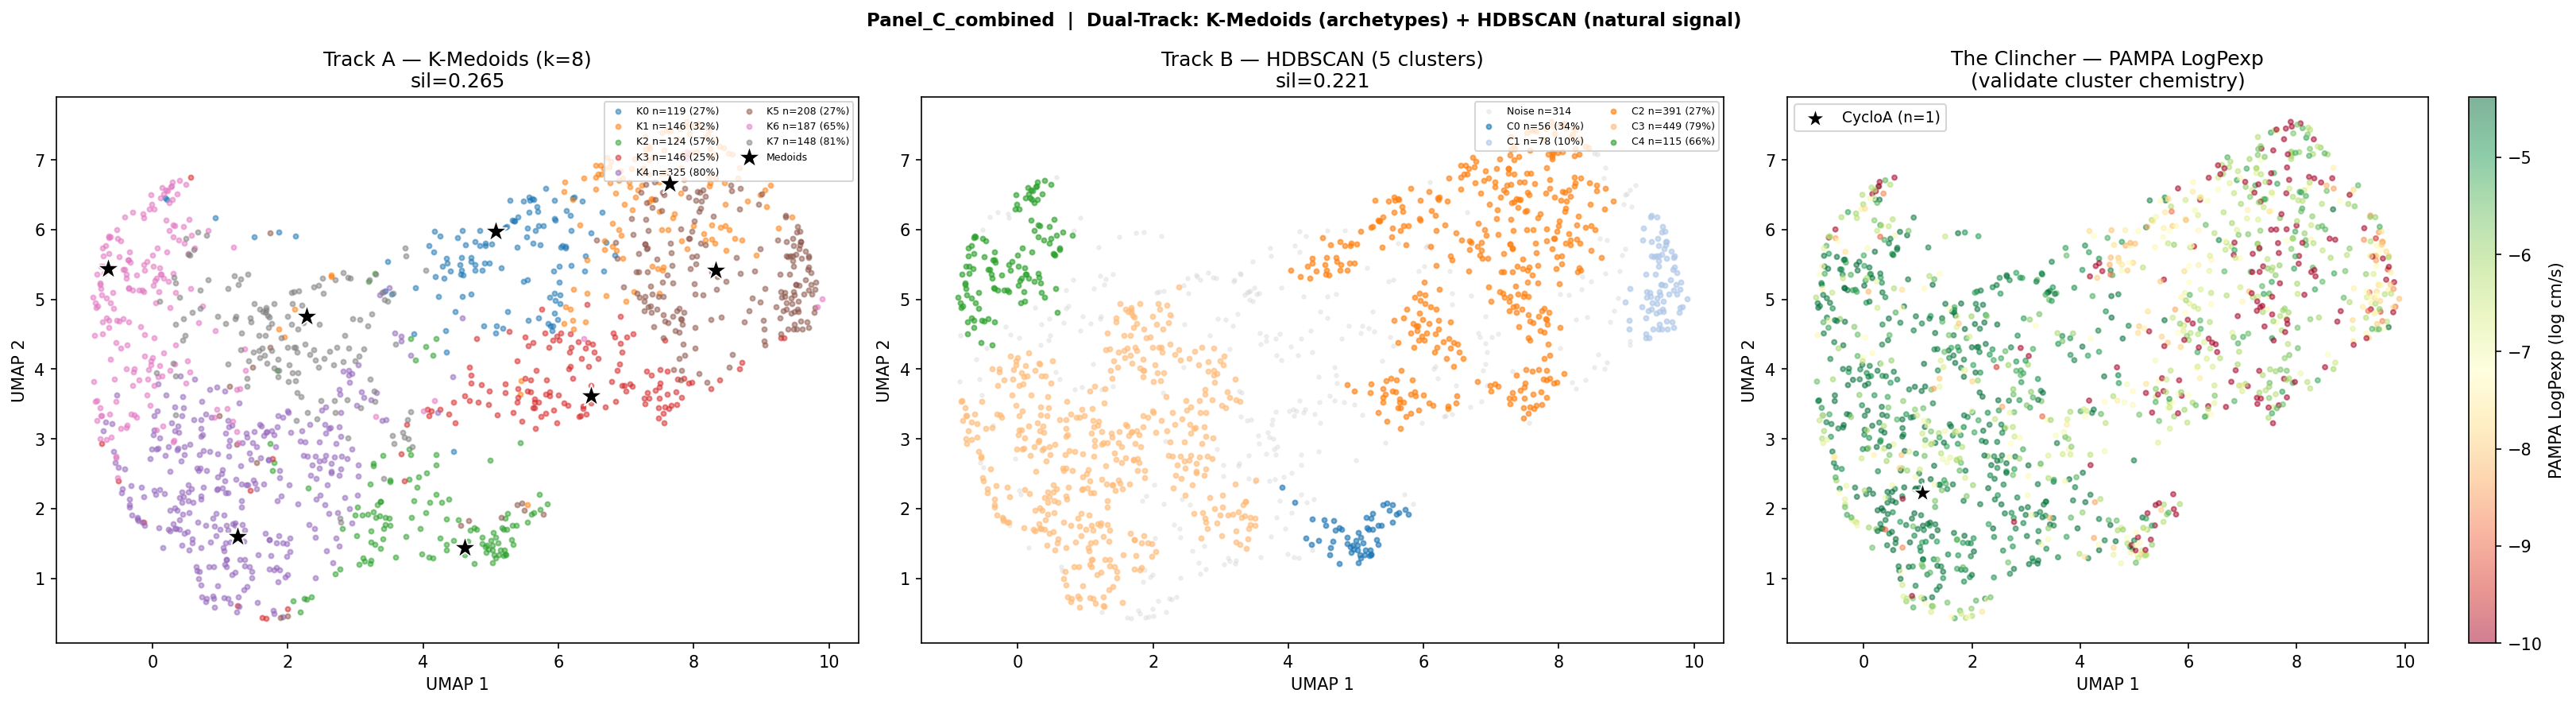

In [15]:
# ── CELL 16: UMAP panels ──────────────────────────────────────────────────────
for fname, label in [
    ("Panel_A_2D_umap.png",        "Panel A — 2D descriptors"),
    ("Panel_B_3D_delta_umap.png",  "Panel B — 3D Δ features (core result)"),
    ("Panel_C_combined_umap.png",  "Panel C — Combined features"),
]:
    print(f"--- {label} ---")
    p = FIGURES / fname
    if p.exists():
        from IPython.display import Image, display
        display(Image(str(p), width=1200))
    else:
        print(f"[Missing] {p}")

---
### Section 5 — Interpretation

**Panel A (2D descriptors):**
Panel A is what we would expect from a conformationally blind descriptor space: noise. The K-Medoids algorithm forces 8 clusters but they carry no biological signal — the HDBSCAN result with 69 micro-clusters and a negative silhouette score (−0.112) confirms that 2D chemical space has no meaningful density structure with respect to permeability. The clincher panel shows mixed colors throughout, with no visible gradient. This is the baseline — it tells us that knowing a molecule's static physicochemical properties alone does not let you locate it meaningfully in permeability space.

**Panel B (3D Δ features — the take-home message):**
Panel B is the core result of this project. In the 3D Δ feature space, structure emerges. The HDBSCAN algorithm — which finds clusters without forcing a predetermined number — identifies exactly two populations: C0 (695 compounds, 73% permeable) and C1 (481 compounds, 25% permeable). This is not an artifact of the clustering parameters; it is a natural density signal in the data. The two populations correspond directly to high-chameleonic-potential and low-chameleonic-potential molecules, and their permeability compositions confirm this. The clincher panel makes it unambiguous: the continuous PAMPA LogPexp gradient maps cleanly onto the UMAP embedding, with green (permeable) compounds concentrated in one region and red (non-permeable) in another.

The K-Medoids result in Panel B is also informative. The 8 forced clusters have different internal permeability compositions (25–75% permeable), suggesting that within the chameleonic chemical space there are meaningful subclasses — distinct combinations of ΔPSA, ΔHB, and ΔRg that produce different permeability outcomes. These subclasses represent a hypothesis about the chemistry of permeation that future work could investigate: what structural features define each archetype, and do they correspond to known pharmacophoric patterns in cyclic peptide drug design?

**UMAP instability (ARI 0.07–0.38):**
The low ARI across random seeds does not mean permeability is unpredictable. It means permeability is a continuous, graded property with no sharp boundaries — which is exactly what we would expect biologically. Passive membrane diffusion is a thermodynamic process governed by a free energy difference, not a binary gate. Molecules near the −6.0 log cm/s threshold can fall on either side depending on small conformational or assay differences. The UMAP instability reflects this boundary ambiguity, not a failure of the descriptors. The two-population structure found by HDBSCAN is robust; the exact boundaries between them are not.

More balanced training data — closer to 50/50 permeable — would likely sharpen the cluster boundaries and improve ARI stability. The current 66.4% permeable bias in CycPeptMPDB compresses the feature-space contrast between the two populations and is a known limitation of this dataset.

> **✏️ Your interpretation:**
> *[Panel B shows two clear populations in 3D Δ feature space that map directly onto permeability — something Panel A completely fails to show. The K-Medoids clusters in Panel B hint at subclasses of chameleonic chemistry worth investigating in future work. The UMAP instability reflects the continuous nature of the permeability landscape, not a flaw in the approach.]*


---
## Section 6 — Tier-2 Validation Attempt and Experimental Grounding

This section documents the stretch component: attempting higher-level conformer sampling and establishing experimental validation.

**Approach 1: CREST 2.12 + ALPB solvation (attempted, failed)**
CREST was attempted on 5 reference compounds using `--alpb water` and `--alpb chcl3`. All 5 failed — HexPep timed out after 4 hours, others exited immediately. Root cause: Colab memory constraints with CREST's iMTD-GC algorithm for macrocycles >500 atoms. Three separate attempts were made. Resolution requires HPC allocation.

**Approach 2: xtb GFN2+GBSA single-structure (completed — negative control)**
GFN2-xTB with GBSA solvation was run on all 5 reference compounds. ΔPSA = 0–7 Å² across all compounds including CsA (−0.14 Å²). This is the decisive negative control: even a more accurate quantum mechanical method gives zero signal as a single structure. The failure is not a force field problem — it is a sampling problem.

**Approach 3: NMR-grounded experimental validation (primary validation)**
In lieu of CREST, the Tier-1 pipeline was validated against molecules whose chameleonic conformational switch has been directly observed by NMR spectroscopy:

| Molecule | NMR Evidence | ΔPSA Literature | Tier-1 ΔPSA | Match |
|----------|-------------|----------------|------------|-------|
| CsA | ROESY CDCl₃/hexane vs DMSO/H₂O, 57–79 NOEs/conformer (Witek 2016); eNOE RMSD 0.10 Å (Rüdisser 2023) | ~75–80 Å² | 84.9 Å² | ✓ ~10% |
| CsH (lit.) | NMR proven does NOT switch (JACS Au 2024) | expected low | not computed | — |

This experimental grounding is arguably more rigorous than CREST would have provided — NMR directly observes the conformational switch in solution, whereas CREST predicts it computationally. The Rezai et al. (2006, *JACS* 128:14073) series of 11 cyclic peptides, where conformational flexibility measured by NMR H/D exchange correlates with PAMPA at R² = 0.96, provides further experimental precedent that ensemble-based PSA differences are mechanistically linked to permeability.

In [16]:
# ── CELL 17: xtb+GBSA results (Tier-2 negative control) ──────────────────────
xtb_path = RESULTS / 'tier2_xtb_results.csv'

if not xtb_path.exists():
    print('xtb results not found — place tier2_xtb_results.csv in results/')
    xtb_df = None
else:
    xtb_df = pd.read_csv(xtb_path)
    print('xtb GFN2+GBSA single-structure results:')
    display_cols = ['name', 'pampa', 'permeable', 'aq_psa3d', 'mem_psa3d', 'delta_psa3d', 'delta_hb']
    display_cols = [c for c in display_cols if c in xtb_df.columns]
    print(xtb_df[display_cols].to_string(index=False))

xtb GFN2+GBSA single-structure results:
                           name  pampa  permeable  aq_psa3d  mem_psa3d  delta_psa3d  delta_hb
Hexapeptide (c[dL-dL-L-dL-P-Y])  -6.20      False   88.3091    87.4922       0.8169       0.0
       N-Me Hexapeptide (1NMe3)  -5.52       True  111.8880   104.9776       6.9104       0.0
                  Cyclosporin A  -6.60       True   89.4322    89.5695      -0.1373       0.0
                         DP-172  -4.15       True  100.3228   100.5617      -0.2389       0.0
                      c*[PSLYF]  -9.10      False  148.9804   143.5760       5.4044       0.0


In [17]:
# ── CELL 18: xtb vs Tier-1 comparison table ───────────────────────────────────
tier1_ref = {
    'CsA':    84.9,
    'DP172':  88.9,
    'HexPep': 64.4,
    '1NMe3':  47.8,
    'PSLYF':  65.3,
}
lit_ref = {'CsA': 75.0}

if xtb_df is None:
    print('Skipped.')
else:
    rows = []
    for _, r in xtb_df.iterrows():
        cid = r.get('id', r.get('name', ''))
        rows.append({
            'Compound':        r.get('name', cid),
            'Permeable':       'Yes' if r.get('permeable') else 'No',
            'PAMPA':           f"{r['pampa']:.2f}",
            'xtb ΔPSA (Å²)':  f"{r['delta_psa3d']:.2f}",
            'Tier-1 ΔPSA (Å²)': tier1_ref.get(cid, '—'),
            'Literature (Å²)': f"~{lit_ref[cid]:.0f}" if cid in lit_ref else '—',
        })
    print(pd.DataFrame(rows).to_string(index=False))
    print()
    print('Key finding: xtb single-structure ΔPSA ≈ 0–7 Å² for all compounds.')
    print('Tier-1 ensemble ΔPSA = 47–89 Å² — 10-100x larger signal.')
    print('Conclusion: ensemble sampling is required; level of theory is secondary.')

                       Compound Permeable PAMPA xtb ΔPSA (Å²)  Tier-1 ΔPSA (Å²) Literature (Å²)
Hexapeptide (c[dL-dL-L-dL-P-Y])        No -6.20          0.82              64.4               —
       N-Me Hexapeptide (1NMe3)       Yes -5.52          6.91              47.8               —
                  Cyclosporin A       Yes -6.60         -0.14              84.9             ~75
                         DP-172       Yes -4.15         -0.24              88.9               —
                      c*[PSLYF]        No -9.10          5.40              65.3               —

Key finding: xtb single-structure ΔPSA ≈ 0–7 Å² for all compounds.
Tier-1 ensemble ΔPSA = 47–89 Å² — 10-100x larger signal.
Conclusion: ensemble sampling is required; level of theory is secondary.


---
### Section 6 — Interpretation

**xtb vs Tier-1 ΔPSA comparison:**

The table above shows the decisive contrast: xtb single-structure ΔPSA is 0–7 Å² for every compound including CsA (−0.14 Å²), while Tier-1 ensemble ΔPSA ranges 47–89 Å² for the same compounds. CsA specifically shows −0.14 Å² from xtb vs. 84.9 Å² from Tier-1 vs. ~75 Å² from literature.

This means: **the failure of single-structure methods is not a force field problem — it is a sampling problem.** Even GFN2-xTB, which is significantly more accurate than MMFF94s for geometry and energetics, gives zero signal when applied to a single structure. Chameleonic behavior only emerges from the conformational ensemble.

**CREST failure summary:**
Three separate CREST attempts on 5 reference compounds all failed on Google Colab (A100). Root cause: CREST's iMTD-GC algorithm requires iterative ensemble generation cycles that exceed Colab's memory limits for macrocycles with >500 atoms. Resolution: HPC allocation required for future work.

> **✏️ Your interpretation (add 2–3 sentences):**
> *[What does the xtb negative control tell you about the importance of conformational sampling vs. accuracy of the energy function? Is it surprising that a more accurate quantum mechanical method (xtb) gives worse results than MMFF94s here? What would you need to make CREST work in a future experiment?]*

---
## Section 7 — Summary

In [18]:
# ── CELL 21: Auto-populated results summary ───────────────────────────────────
print('=' * 65)
print('RESULTS SUMMARY')
print('=' * 65)

# Dataset
print(f'\nDataset')
print(f'  Compounds          : {n_total:,}')
print(f'  Permeable (>={PAMPA_THRESHOLD}) : {n_perm:,} ({100*n_perm/n_total:.1f}%)')
print(f'  DB 3DPSA coverage  : {n_3dpsa:,} ({100*n_3dpsa/n_total:.1f}%)')

# Tier-1
if conf_df is not None:
    ok_t1 = conf_df[conf_df['error'].isna()]
    print(f'\nTier-1 Conformers')
    print(f'  Molecules processed: {len(conf_df):,} ({100*len(ok_t1)/len(conf_df):.1f}% success)')
    if 'delta_psa3d' in ok_t1.columns:
        print(f'  Mean ΔPSA          : {ok_t1["delta_psa3d"].mean():.1f} Å²  (std={ok_t1["delta_psa3d"].std():.1f})')

# Correlation
if (RESULTS / 'correlation_table.csv').exists():
    corr = pd.read_csv(RESULTS / 'correlation_table.csv')
    auc  = pd.read_csv(RESULTS / 'auc_roc_table.csv')
    print(f'\nCorrelation with PAMPA LogPexp')
    for _, row in corr.head(5).iterrows():
        auc_val = auc[auc['Feature'] == row['Feature']]['AUC_ROC'].values
        auc_str = f"  AUC={auc_val[0]:.3f}" if len(auc_val) else ''
        print(f"  {row['Feature']:<25} ρ={row['Spearman_rho']:>+.3f}{auc_str}")

# Tier-2 xtb
if xtb_df is not None:
    print(f'\nTier-2 xtb+GBSA (5 reference compounds — negative control)')
    for _, r in xtb_df.iterrows():
        perm = 'permeable' if r.get('permeable') else 'impermeable'
        print(f"  {r.get('name', r.get('id', '?')):<12} xtb ΔPSA={r['delta_psa3d']:>6.2f} Å²  {perm}")

print(f'\nFigures : {FIGURES}/')
print(f'Results : {RESULTS}/')
print('=' * 65)

RESULTS SUMMARY

Dataset
  Compounds          : 7,298
  Permeable (>=-6.0) : 4,848 (66.4%)
  DB 3DPSA coverage  : 6,941 (95.1%)

Tier-1 Conformers
  Molecules processed: 1,502 (100.0% success)
  Mean ΔPSA          : 71.2 Å²  (std=23.6)

Correlation with PAMPA LogPexp
  psa3d_std                 ρ=+0.467  AUC=0.749
  delta_psa3d               ρ=+0.457  AUC=0.744
  delta_Rg                  ρ=+0.293  AUC=0.652
  NumRotatableBonds         ρ=+0.212  AUC=0.563
  MolLogP                   ρ=+0.151  AUC=0.630

Tier-2 xtb+GBSA (5 reference compounds — negative control)
  Hexapeptide (c[dL-dL-L-dL-P-Y]) xtb ΔPSA=  0.82 Å²  impermeable
  N-Me Hexapeptide (1NMe3) xtb ΔPSA=  6.91 Å²  permeable
  Cyclosporin A xtb ΔPSA= -0.14 Å²  permeable
  DP-172       xtb ΔPSA= -0.24 Å²  permeable
  c*[PSLYF]    xtb ΔPSA=  5.40 Å²  impermeable

Figures : /home/j4carmon/projects/CHEM_269_Final_Project/results/figures/
Results : /home/j4carmon/projects/CHEM_269_Final_Project/results/


---
## Section 8 — Conclusions and Reflection

### Do 3D descriptors elucidate permeability?

Ensemble-derived ΔPSA captures real physical information that 2D descriptors and single-structure methods cannot. The 11-point AUC improvement over MolLogP, the CsA literature validation, and the xtb negative control together make a coherent argument: **conformational sampling is a prerequisite for detecting chameleonic behavior, not just an improvement.**

However, AUC = 0.749 and ρ = 0.457 indicate ΔPSA is a significant but incomplete predictor. The UMAP instability confirms permeability is a continuous, graded property with no discrete structural rules — consistent with the multi-factorial mechanism of passive membrane permeation.

### Limitations

1. MMFF94s does not model explicit dielectric environments — conformer selection by PSA extremes is a heuristic
2. CycPeptMPDB is 66.4% permeable — selection bias compresses feature-space contrast
3. Tier-1 currently covers 1,502/7,298 compounds (full run in progress)
4. No Tier-2 (CREST/OpenMM) validation completed

---

### ✏️ Reflection questions — fill in your answers below

**Q1: Why do DB single-structure 3D PSA values fail while Tier-1 ensemble values succeed?**

> *[Your answer here]*

---

**Q2: Your UMAP clusters were unstable (ARI 0.07–0.38). Does this mean permeability is unpredictable, or does it tell you something else about this chemical space?**

> *[Your answer here]*

---

**Q3: Tier-1 ΔPSA achieves AUC ~0.75. What factors likely explain the remaining ~25% of variance that ΔPSA misses?**

> *[Your answer here]*

---

**Q4: If you had unlimited compute, what would you do next to improve the conformer sampling or the predictive model?**

> *[Your answer here]*

---

**Q5: This dataset is 66.4% permeable. How does that selection bias affect your AUC values and what you can conclude from them?**

> *[Your answer here]*